In [1]:
%pip --quiet install git+https://github.com/mfinzi/equivariant-MLP.git

     |████████████████████████████████| 50 kB 4.2 MB/s 
     |████████████████████████████████| 470 kB 20.0 MB/s 
     |████████████████████████████████| 126 kB 50.2 MB/s 
     |████████████████████████████████| 65 kB 3.2 MB/s 


In [2]:
from emlp.nn import EMLP, EMLPBlock, GatedNonlinearity, uniform_rep, Sequential
from emlp.groups import SO,SU#,O,S,Z, SO13p, SO13, O13
from emlp.reps import Rep, vis, V, Scalar
from emlp.datasets import Inertia

import jax.numpy as jnp
import numpy as np
import objaximport objax.nn as nn
from tqdm.auto import tqdm
from torch.utils.data import DataLoader
from jax import vmap

import matplotlib.pyplot as plt

In [12]:
import jax
import jax.numpy as jnp
import objax.nn as nn
import objax.functional as F
import numpy as np
from emlp.reps import T,Rep,Scalar
from emlp.reps import bilinear_weights
from emlp.reps.product_sum_reps import SumRep
import collections
from emlp.utils import Named,export
import scipy as sp
import scipy.special
import random
import logging
from objax.variable import TrainVar, StateVar
from objax.nn.init import kaiming_normal, xavier_normal
from objax.module import Module
import objax
from objax.nn.init import orthogonal
from scipy.special import binom
from jax import jit,vmap
from functools import lru_cache as cache

def Sequential(*args):
    """ Wrapped to mimic pytorch syntax"""
    return nn.Sequential(args)

@export
class Linear(nn.Linear):
    """ Basic equivariant Linear layer from repin to repout."""
    def __init__(self, repin, repout):
        nin,nout = repin.size(),repout.size()
        super().__init__(nin,nout)
        self.b = TrainVar(objax.random.uniform((nout,))/jnp.sqrt(nout))
        self.w = TrainVar(orthogonal((nout, nin)))
        self.rep_W = rep_W = repout*repin.T
        
        rep_bias = repout
        self.Pw = rep_W.equivariant_projector()
        self.Pb = rep_bias.equivariant_projector()
        logging.info(f"Linear W components:{rep_W.size()} rep:{rep_W}")
    def __call__(self, x): # (cin) -> (cout)
        logging.debug(f"linear in shape: {x.shape}")
        W = (self.Pw@self.w.value.reshape(-1)).reshape(*self.w.value.shape)
        b = self.Pb@self.b.value
        out = x@W.T+b
        logging.debug(f"linear out shape:{out.shape}")
        return out


@export
class BiLinear(Module):
    """ Cheap bilinear layer (adds parameters for each part of the input which can be
        interpreted as a linear map from a part of the input to the output representation)."""
    def __init__(self, repin, repout):
        super().__init__()
        Wdim, weight_proj = bilinear_weights(repout,repin)
        self.weight_proj = jit(weight_proj)
        self.w = TrainVar(objax.random.normal((Wdim,)))
        logging.info(f"BiW components: dim:{Wdim}")

    def __call__(self, x,training=True):
        # compatible with non sumreps? need to check
        W = self.weight_proj(self.w.value,x)
        out= .1*(W@x[...,None])[...,0]
        return out


@export
def gated(ch_rep:Rep) -> Rep:
    """ Returns the rep with an additional scalar 'gate' for each of the nonscalars and non regular
        reps in the input. To be used as the output for linear (and or bilinear) layers directly
        before a :func:`GatedNonlinearity` to produce its scalar gates. """
    if isinstance(ch_rep,SumRep):
        return ch_rep+sum([Scalar(rep.G) for rep in ch_rep if rep!=Scalar and not rep.is_permutation])
    else:
        return ch_rep+Scalar(ch_rep.G) if not ch_rep.is_permutation else ch_rep

@export
def gated_custom(ch_rep:Rep) -> Rep:
    """ Returns the rep with an additional scalar 'gate' for each of the nonscalars and non regular
        reps in the input. To be used as the output for linear (and or bilinear) layers directly
        before a :func:`GatedNonlinearity` to produce its scalar gates. """
    if isinstance(ch_rep,SumRep):
        return ch_rep+sum([Scalar(rep.G) for rep in ch_rep if not rep.is_permutation])
    else:
        return ch_rep+Scalar(ch_rep.G) if not ch_rep.is_permutation else ch_rep


@export
class GatedNonlinearity(Module):
    """ Gated nonlinearity. Requires input to have the additional gate scalars
        for every non regular and non scalar rep. Applies swish to regular and
        scalar reps. """
    def __init__(self,rep):
        super().__init__()
        self.rep=rep
    def __call__(self,values):
        gate_scalars = values[..., gate_indices(self.rep)]
        activations = jax.nn.sigmoid(gate_scalars) * values[..., :self.rep.size()]
        return activations

@export
class GatedNonlinearity_custom(Module):
    """ Gated nonlinearity. Requires input to have the additional gate scalars
        for every non regular and non scalar rep. Applies swish to regular and
        scalar reps. """
    def __init__(self,rep):
        super().__init__()
        self.rep=rep
    def __call__(self,values):
        gate_scalars = values[..., gate_indices_custom(self.rep)]
        activations = jax.nn.sigmoid(gate_scalars) * values[..., :self.rep.size()]
        return activations


@export
class EMLPBlock(Module):
    """ Basic building block of EMLP consisting of G-Linear, biLinear,
        and gated nonlinearity. """
    def __init__(self,rep_in,rep_out):
        super().__init__()
        self.linear = Linear(rep_in,gated(rep_out))
        self.bilinear = BiLinear(gated(rep_out),gated(rep_out))
        self.nonlinearity = GatedNonlinearity(rep_out)
    def __call__(self,x):
        lin = self.linear(x)
        preact =self.bilinear(lin)+lin
        return self.nonlinearity(preact)

@export
class EMLPBlock_custom(Module):
    """ Basic building block of EMLP consisting of G-Linear, biLinear,
        and gated nonlinearity. """
    def __init__(self,rep_in,rep_out):
        super().__init__()
        self.linear = Linear(rep_in,gated(rep_out))
        self.bilinear = BiLinear(gated(rep_out),gated(rep_out))
        self.nonlinearity = GatedNonlinearity_custom(rep_out)
    def __call__(self,x):
        lin = self.linear(x)
        preact =self.bilinear(lin)+lin
        return self.nonlinearity(preact)


def uniform_rep_general(ch,*rep_types):
    """ adds all combinations of (powers of) rep_types up to
        a total size of ch channels. """
    raise NotImplementedError
    
    
    

@export
def uniform_rep(ch,group):
    """ A heuristic method for allocating a given number of channels (ch)
        into tensor types. Attempts to distribute the channels evenly across
        the different tensor types. Useful for hands off layer construction.
        
        Args:
            ch (int): total number of channels
            group (Group): symmetry group

        Returns:
            SumRep: The direct sum representation with dim(V)=ch
        """
    d = group.d
    Ns = np.zeros((lambertW(ch,d)+1,),int) # number of tensors of each rank
    while ch>0:
        max_rank = lambertW(ch,d) # compute the max rank tensor that can fit up to
        Ns[:max_rank+1] += np.array([d**(max_rank-r) for r in range(max_rank+1)],dtype=int)
        ch -= (max_rank+1)*d**max_rank # compute leftover channels
    sum_rep = sum([binomial_allocation(nr,r,group) for r,nr in enumerate(Ns)])
    sum_rep,perm = sum_rep.canonicalize()
    return sum_rep


def lambertW(ch,d):
    """ Returns solution to x*d^x = ch rounded down."""
    max_rank=0
    while (max_rank+1)*d**max_rank <= ch:
        max_rank += 1
    max_rank -= 1
    return max_rank

def binomial_allocation(N,rank,G):
    """ Allocates N of tensors of total rank r=(p+q) into
        T(k,r-k) for k=0,1,...,r to match the binomial distribution.
        For orthogonal representations there is no
        distinction between p and q, so this op is equivalent to N*T(rank)."""
    if N==0: return 0
    n_binoms = N//(2**rank)
    n_leftover = N%(2**rank)
    even_split = sum([n_binoms*int(binom(rank,k))*T(k,rank-k,G) for k in range(rank+1)])
    ps = np.random.binomial(rank,.5,n_leftover)
    ragged = sum([T(int(p),rank-int(p),G) for p in ps])
    out = even_split+ragged
    return out

def uniform_allocation(N,rank):
    """ Uniformly allocates N of tensors of total rank r=(p+q) into
        T(k,r-k) for k=0,1,...,r. For orthogonal representations there is no
        distinction between p and q, so this op is equivalent to N*T(rank)."""
    if N==0: return 0
    even_split = sum((N//(rank+1))*T(k,rank-k) for k in range(rank+1))
    ragged = sum(random.sample([T(k,rank-k) for k in range(rank+1)],N%(rank+1)))
    return even_split+ragged

@export
class EMLP(Module,metaclass=Named):
    """ Equivariant MultiLayer Perceptron. 
        If the input ch argument is an int, uses the hands off uniform_rep heuristic.
        If the ch argument is a representation, uses this representation for the hidden layers.
        Individual layer representations can be set explicitly by using a list of ints or a list of
        representations, rather than use the same for each hidden layer.

        Args:
            rep_in (Rep): input representation
            rep_out (Rep): output representation
            group (Group): symmetry group
            ch (int or list[int] or Rep or list[Rep]): number of channels in the hidden layers
            num_layers (int): number of hidden layers

        Returns:
            Module: the EMLP objax module."""
    def __init__(self,rep_in,rep_out,group,ch=384,num_layers=3):#@
        super().__init__()
        logging.info("Initing EMLP (objax)")
        self.rep_in =rep_in(group)
        self.rep_out = rep_out(group)
        
        self.G=group
        # Parse ch as a single int, a sequence of ints, a single Rep, a sequence of Reps
        if isinstance(ch,int): middle_layers = num_layers*[uniform_rep(ch,group)]#[uniform_rep(ch,group) for _ in range(num_layers)]
        elif isinstance(ch,Rep): middle_layers = num_layers*[ch(group)]
        else: middle_layers = [(c(group) if isinstance(c,Rep) else uniform_rep(c,group)) for c in ch]
        #assert all((not rep.G is None) for rep in middle_layers[0].reps)
        reps = [self.rep_in]+middle_layers
        logging.info(f"Reps: {reps}")
        self.network = Sequential(
            *[EMLPBlock(rin,rout) for rin,rout in zip(reps,reps[1:])],
            Linear(reps[-1],self.rep_out)
        )
    def __call__(self,x,training=True):
        return self.network(x)

@export
class EMLP_custom(Module,metaclass=Named):
    """ Equivariant MultiLayer Perceptron. 
        If the input ch argument is an int, uses the hands off uniform_rep heuristic.
        If the ch argument is a representation, uses this representation for the hidden layers.
        Individual layer representations can be set explicitly by using a list of ints or a list of
        representations, rather than use the same for each hidden layer.

        Args:
            rep_in (Rep): input representation
            rep_out (Rep): output representation
            group (Group): symmetry group
            ch (int or list[int] or Rep or list[Rep]): number of channels in the hidden layers
            num_layers (int): number of hidden layers

        Returns:
            Module: the EMLP objax module."""
    def __init__(self,rep_in,rep_out,group,ch=384,num_layers=3):#@
        super().__init__()
        logging.info("Initing EMLP (objax)")
        self.rep_in =rep_in(group)
        self.rep_out = rep_out(group)
        
        self.G=group
        # Parse ch as a single int, a sequence of ints, a single Rep, a sequence of Reps
        if isinstance(ch,int): middle_layers = num_layers*[uniform_rep(ch,group)]#[uniform_rep(ch,group) for _ in range(num_layers)]
        elif isinstance(ch,Rep): middle_layers = num_layers*[ch(group)]
        else: middle_layers = [(c(group) if isinstance(c,Rep) else uniform_rep(c,group)) for c in ch]
        #assert all((not rep.G is None) for rep in middle_layers[0].reps)
        reps = [self.rep_in]+middle_layers
        logging.info(f"Reps: {reps}")
        self.network = Sequential(
            *[EMLPBlock_custom(rin,rout) for rin,rout in zip(reps,reps[1:])],
            Linear(reps[-1],self.rep_out)
        )
    def __call__(self,x,training=True):
        return self.network(x)

def swish(x):
    return jax.nn.sigmoid(x)*x

def MLPBlock(cin,cout):
    return Sequential(nn.Linear(cin,cout),swish)#,nn.BatchNorm0D(cout,momentum=.9),swish)#,

@export
class MLP(Module,metaclass=Named):
    """ Standard baseline MLP. Representations and group are used for shapes only. """
    def __init__(self,rep_in,rep_out,group,ch=384,num_layers=3):
        super().__init__()
        self.rep_in =rep_in(group)
        self.rep_out = rep_out(group)
        self.G = group
        chs = [self.rep_in.size()] + num_layers*[ch]
        cout = self.rep_out.size()
        logging.info("Initing MLP")
        self.net = Sequential(
            *[MLPBlock(cin,cout) for cin,cout in zip(chs,chs[1:])],
            nn.Linear(chs[-1],cout)
        )
    def __call__(self,x,training=True):
        y = self.net(x)
        return y


@export
class Standardize(Module):
    """ A convenience module to wrap a given module, normalize its input
        by some dataset x mean and std stats, and unnormalize its output by
        the dataset y mean and std stats. 

        Args:
            model (Module): model to wrap
            ds_stats ((μx,σx,μy,σy) or (μx,σx)): tuple of the normalization stats
        
        Returns:
            Module: Wrapped model with input normalization (and output unnormalization)"""
    def __init__(self,model,ds_stats):
        super().__init__()
        self.model = model
        self.ds_stats=ds_stats
    def __call__(self,x,training):
        if len(self.ds_stats)==2:
            muin,sin = self.ds_stats
            return self.model((x-muin)/sin,training=training)
        else:
            muin,sin,muout,sout = self.ds_stats
            y = sout*self.model((x-muin)/sin,training=training)+muout
            return y




# Networks for hamiltonian dynamics (need to sum for batched Hamiltonian grads)
@export
class MLPode(Module,metaclass=Named):
    def __init__(self,rep_in,rep_out,group,ch=384,num_layers=3):
        super().__init__()
        self.rep_in =rep_in(group)
        self.rep_out = rep_out(group)
        self.G = group
        chs = [self.rep_in.size()] + num_layers*[ch]
        cout = self.rep_out.size()
        logging.info("Initing MLP")
        self.net = Sequential(
            *[Sequential(nn.Linear(cin,cout),swish) for cin,cout in zip(chs,chs[1:])],
            nn.Linear(chs[-1],cout)
        )
    def __call__(self,z,t):
        return self.net(z)


@export
class EMLPode(EMLP):
    """ Neural ODE Equivariant MLP. Same args as EMLP."""
    #__doc__ += EMLP.__doc__.split('.')[1]
    def __init__(self,rep_in,rep_out,group,ch=384,num_layers=3):#@
        #super().__init__()
        logging.info("Initing EMLP")
        self.rep_in =rep_in(group)
        self.rep_out = rep_out(group)
        self.G=group
        # Parse ch as a single int, a sequence of ints, a single Rep, a sequence of Reps
        if isinstance(ch,int): middle_layers = num_layers*[uniform_rep(ch,group)]#[uniform_rep(ch,group) for _ in range(num_layers)]
        elif isinstance(ch,Rep): middle_layers = num_layers*[ch(group)]
        else: middle_layers = [(c(group) if isinstance(c,Rep) else uniform_rep(c,group)) for c in ch]
        #print(middle_layers[0].reps[0].G)
        #print(self.rep_in.G)
        reps = [self.rep_in]+middle_layers
        logging.info(f"Reps: {reps}")
        self.network = Sequential(
            *[EMLPBlock(rin,rout) for rin,rout in zip(reps,reps[1:])],
            Linear(reps[-1],self.rep_out)
        )
    def __call__(self,z,t):
        return self.network(z)


# Networks for hamiltonian dynamics (need to sum for batched Hamiltonian grads)
@export
class MLPH(Module,metaclass=Named):
    def __init__(self,rep_in,rep_out,group,ch=384,num_layers=3):
        super().__init__()
        self.rep_in =rep_in(group)
        self.rep_out = rep_out(group)
        self.G = group
        chs = [self.rep_in.size()] + num_layers*[ch]
        cout = self.rep_out.size()
        logging.info("Initing MLP")
        self.net = Sequential(
            *[Sequential(nn.Linear(cin,cout),swish) for cin,cout in zip(chs,chs[1:])],
            nn.Linear(chs[-1],cout)
        )
    def H(self,x):#,training=True):
        y = self.net(x).sum()
        return y
    def __call__(self,x):
        return self.H(x)


@export
class EMLPH(EMLP):
    """ Equivariant EMLP modeling a Hamiltonian for HNN. Same args as EMLP"""
    #__doc__ += EMLP.__doc__.split('.')[1]
    def H(self,x):#,training=True):
        y = self.network(x)
        return y.sum()
    def __call__(self,x):
        return self.H(x)


@export
@cache(maxsize=None)
def gate_indices(ch_rep:Rep) -> jnp.ndarray:
    """ Indices for scalars, and also additional scalar gates
        added by gated(sumrep)"""
    channels = ch_rep.size()
    perm = ch_rep.perm
    indices = np.arange(channels)

    if not isinstance(ch_rep,SumRep): # If just a single rep, only one scalar at end
        return indices if ch_rep.is_permutation else np.ones(ch_rep.size())*ch_rep.size()

    num_nonscalars = 0
    i=0
    for rep in ch_rep:
        if rep!=Scalar and not rep.is_permutation:
            indices[perm[i:i+rep.size()]] = channels+num_nonscalars
            num_nonscalars+=1
        i+=rep.size()
    return indices


@export
@cache(maxsize=None)
def gate_indices_custom(ch_rep:Rep) -> jnp.ndarray:
    """ Indices for scalars, and also additional scalar gates
        added by gated(sumrep)"""
    channels = ch_rep.size()
    perm = ch_rep.perm
    indices = np.arange(channels)

    if not isinstance(ch_rep,SumRep): # If just a single rep, only one scalar at end
        return indices if ch_rep.is_permutation else np.ones(ch_rep.size())*ch_rep.size()

    num_nonscalars = 0
    i=0
    for rep in ch_rep:
        if not rep.is_permutation:
            indices[perm[i:i+rep.size()]] = channels+num_nonscalars
            num_nonscalars+=1
        i+=rep.size()
    return indices

In [13]:
from emlp.groups import SO#,O,S,Z, SO13p, SO13, O13
from emlp.reps import vis, V
from emlp.datasets import Inertia

import jax.numpy as jnp
import numpy as np
import objax
import objax.nn as nn
from tqdm.auto import tqdm
from torch.utils.data import DataLoader
from jax import vmap

import matplotlib.pyplot as plt

class InertiaModel:
    def __init__(self, name) :
        self.name=name
        self.trainset = Inertia(1000) # Initialize dataset with 1000 examples
        self.testset = Inertia(2000)
        self.opt = None
        self.model = None
        self.test_losses = []
        self.train_losses = []
        self.rep_in = None
        self.rep_out = None
        self.testloader = None
        self.trainloder = None
        self.NUM_EPOCHS = None
        self.EMLP_custom = None

    
    def create_EMLP_model(self,rep_in, rep_out, group, num_layers=3 ,ch=384):
        self.model = EMLP(rep_in, rep_out, group, num_layers=num_layers, ch=ch)
        self.opt = objax.optimizer.Adam(self.model.vars())
        self.rep_in = rep_in
        self.rep_out = rep_out

    def create_custom_model(self,rep_in, rep_out, group, num_layers=3 ,ch=384):
        self.model = EMLP_custom(rep_in, rep_out, group, num_layers=num_layers, ch=ch)
        self.opt = objax.optimizer.Adam(self.model.vars())
        self.rep_in = rep_in
        self.rep_out = rep_out
        
        
   # @objax.Jit
   # @objax.Function.with_vars(self.model.vars())
    def loss(self,x, y):
        yhat = self.model(x)
        return ((yhat-y)**2).mean()
    
  #  @objax.Jit
  #  @objax.Function.with_vars(self.model.vars()+self.opt.vars())
    def train_op(self,x, y, lr):
        grad_and_val = objax.GradValues(self.loss, self.model.vars())
        g, v = grad_and_val(x, y)
        self.opt(lr=lr, grads=g)
        return v
    
    def train_model(self,BS=500, lr=3e-3, NUM_EPOCHS=500):
        self.trainloader = DataLoader(self.trainset,batch_size=BS,shuffle=True)
        self.testloader = DataLoader(self.testset,batch_size=BS,shuffle=True)
        
        jit_loss = objax.Jit(self.loss, self.model.vars())
        jit_train = objax.Jit(self.train_op, self.model.vars()+self.opt.vars())

        self.NUM_EPOCHS=NUM_EPOCHS
        
        for epoch in tqdm(range(NUM_EPOCHS)):
            self.train_losses.append(np.mean([jit_train(jnp.array(x),jnp.array(y),lr) for (x,y) in self.trainloader]))
            if not epoch%10:
                self.test_losses.append(np.mean([jit_loss(jnp.array(x),jnp.array(y)) for (x,y) in self.testloader]))
    
    def plot_losses(self):
        plt.plot(np.arange(self.NUM_EPOCHS),self.train_losses,label='Train loss')
        plt.plot(np.arange(0,self.NUM_EPOCHS,10),self.test_losses,label='Test loss')
        plt.legend()
        plt.title(self.name)
        plt.yscale('log')
    
    def plot_test_loss(self):
        plt.plot(np.arange(0,self.NUM_EPOCHS,10),self.test_losses,label=self.name)
        plt.legend()
        plt.title('Test losses')
        plt.yscale('log')
        
    def rel_err(a,b):
        return jnp.sqrt(((a-b)**2).mean())/(jnp.sqrt((a**2).mean())+jnp.sqrt((b**2).mean()))

    def equivariance_err(self,mb):
        x,y = mb
        x,y= jnp.array(x),jnp.array(y)
        gs = G.samples(x.shape[0])
        rho_gin = vmap(self.rep_in.rho_dense)(gs)
        rho_gout = vmap(self.rep_out.rho_dense)(gs)
        y1 = model((rho_gin@x[...,None])[...,0],training=False)
        y2 = (rho_gout@model(x,training=False)[...,None])[...,0]
        return rel_err(y1,y2)
    
    def test_equivariance(self):
        print(f"Average test equivariance error {np.mean([self.equivariance_err(mb) for mb in self.testloader]):.2e}")

In [14]:
G = SO(3)
rep_in = 5*Scalar+5*V
rep_out = V*V
rep_scalar = 20*Scalar

In [28]:
model1 = InertiaModel('Default model, l=3, ch=384')
model1.create_EMLP_model(rep_in,rep_out,group=G,num_layers=3,ch=384)
print(uniform_rep(384,G))

102V⁰+34V+11V²+3V³


In [6]:
print("Basis for first weight matrix in default model")
vis(rep_in(G),uniform_rep(384,G))

Basis for first weight matrix in default model


In [7]:
print("Basis for last weight matrix in default model")
vis(uniform_rep(384,G),rep_out(G))

Basis for last weight matrix in default model


  0%|          | 0/500 [00:00<?, ?it/s]

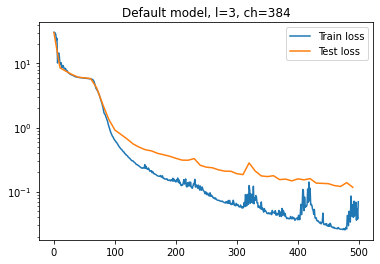

In [29]:
model1.train_model()
model1.plot_losses()

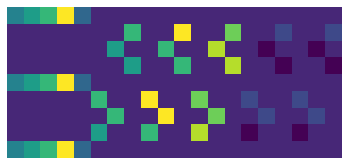

In [9]:
model2 = InertiaModel('Default rep, No hidden layer')
model2.create_EMLP_model(rep_in,rep_out,group=G,num_layers=0)
vis(rep_in(G),rep_out(G))

  0%|          | 0/500 [00:00<?, ?it/s]

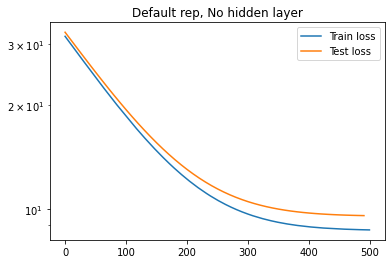

In [10]:
model2.train_model()
model2.plot_losses()

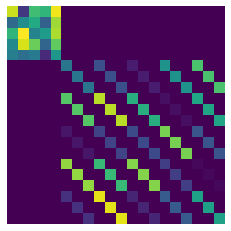

In [11]:
model3 = InertiaModel('Default rep in all hidden layers, l=3, ch=20')
model3.create_EMLP_model(rep_in,rep_out,group=G,num_layers=3,ch=rep_in)
vis(rep_in(G),rep_in(G))

  0%|          | 0/500 [00:00<?, ?it/s]

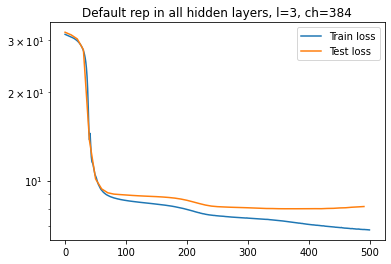

In [12]:
model3.train_model()
model3.plot_losses()

23V⁰+6V+V²


/usr/local/lib/python3.7/dist-packages/emlp/reps/representation.py:473: ConvergenceWarning: Number of distinct clusters (478) found smaller than n_clusters (480). Possibly due to duplicate points in X.
  v = KMeans(n_clusters=Q.shape[-1]).fit(v.reshape(-1,1)).labels_


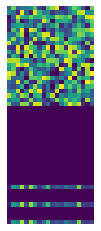

In [21]:
print(uniform_rep(50,G))
vis(rep_scalar(G),uniform_rep(50,G))
model4 = InertiaModel('Only scalars as input rep, l=3, ch=100')
model4.create_EMLP_model(rep_scalar,rep_out,group=G,num_layers=3,ch=100)
model4default = InertiaModel('Default input rep, l=3, ch=100')
model4default.create_EMLP_model(rep_in,rep_out,group=G,num_layers=3,ch=100)

  0%|          | 0/500 [00:00<?, ?it/s]

  0%|          | 0/500 [00:00<?, ?it/s]

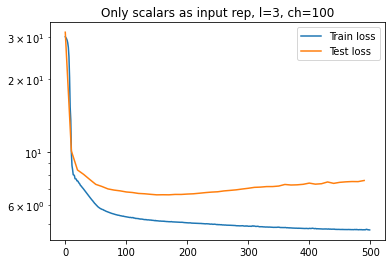

In [22]:
model4.train_model()
model4default.train_model()
model4.plot_losses()

In [31]:
model5 = InertiaModel('Default model, l=3, ch=1000')
model5.create_EMLP_model(rep_in,rep_out,group=G,num_layers=3,ch=1000)
print(uniform_rep(1000,G))
vis(rep_in(G),uniform_rep(1000,G))

Krylov Solving for Equivariant Subspace r<=10:   0%|          | 0/100 [00:00<?, ?it/s]

Krylov Solving for Equivariant Subspace r<=20:   0%|          | 0/100 [00:00<?, ?it/s]

Krylov Solving for Equivariant Subspace r<=40:   0%|          | 0/100 [00:00<?, ?it/s]

Krylov Solving for Equivariant Subspace r<=80:   0%|          | 0/100 [00:00<?, ?it/s]

Krylov Solving for Equivariant Subspace r<=160:   0%|          | 0/100 [00:00<?, ?it/s]

217V⁰+72V+24V²+7V³+2V⁴


  0%|          | 0/500 [00:00<?, ?it/s]

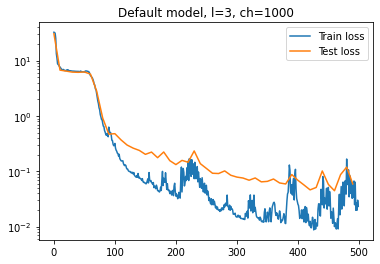

In [32]:
model5.train_model()
model5.plot_losses()

  0%|          | 0/500 [00:00<?, ?it/s]

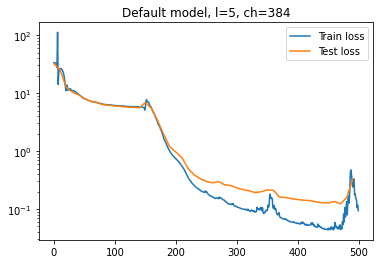

In [29]:
model6a = InertiaModel('Default model, l=5, ch=384')
model6a.create_EMLP_model(rep_in,rep_out,group=G,num_layers=5,ch=384)
model6a.train_model()
model6a.plot_losses()

  0%|          | 0/500 [00:00<?, ?it/s]

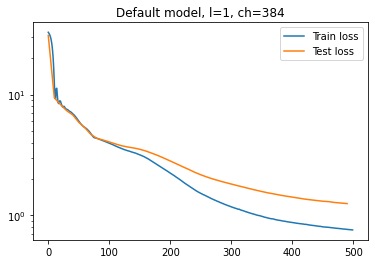

In [22]:
model7 = InertiaModel('Default model, l=1, ch=384')
model7.create_EMLP_model(rep_in,rep_out,group=G,num_layers=1,ch=384)
model7.train_model()
model7.plot_losses()

  0%|          | 0/500 [00:00<?, ?it/s]

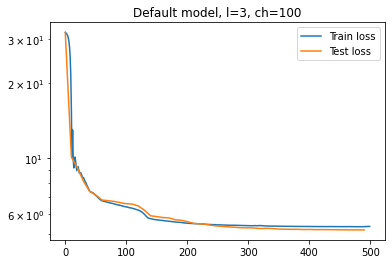

In [30]:
model8 = InertiaModel('Default model, l=3, ch=100')
model8.create_EMLP_model(rep_in,rep_out,group=G,num_layers=3,ch=100)
model8.train_model()
model8.plot_losses()

  0%|          | 0/500 [00:00<?, ?it/s]

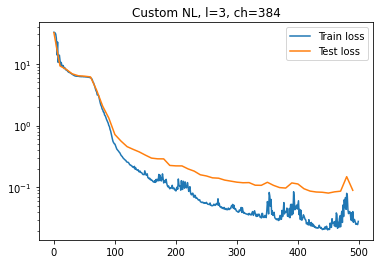

In [27]:
modelc = InertiaModel('Custom NL, l=3, ch=384')
modelc.create_custom_model(rep_in,rep_out,group=G,num_layers=3,ch=384)
modelc.train_model()
modelc.plot_losses()

  0%|          | 0/500 [00:00<?, ?it/s]

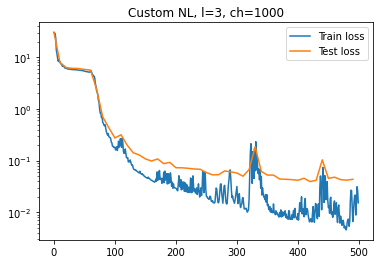

In [33]:
modelc2 = InertiaModel('Custom NL, l=3, ch=1000')
modelc2.create_custom_model(rep_in,rep_out,group=G,num_layers=3,ch=1000)
modelc2.train_model()
modelc2.plot_losses()

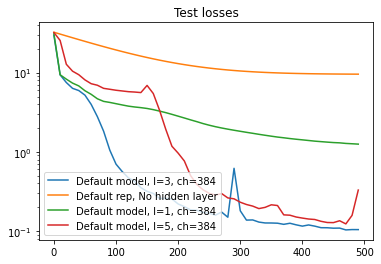

In [31]:
model1.plot_test_loss()
model2.plot_test_loss()
model7.plot_test_loss()
model6a.plot_test_loss()

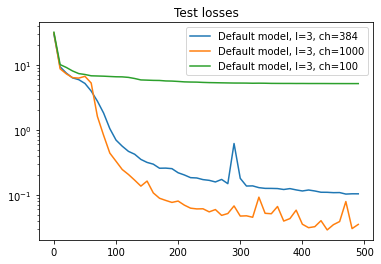

In [32]:
model1.plot_test_loss()
model5.plot_test_loss()
model8.plot_test_loss()

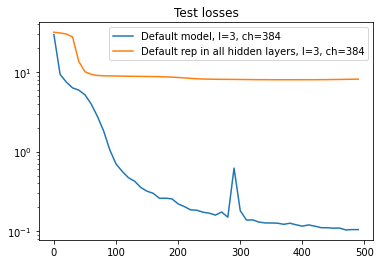

In [26]:
model1.plot_test_loss()
model3.plot_test_loss()

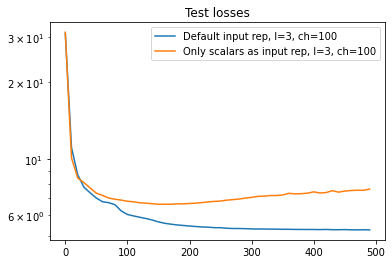

In [25]:
model4default.plot_test_loss()
model4.plot_test_loss()

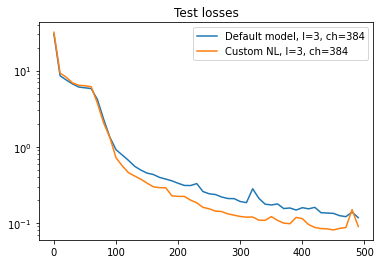

In [30]:
model1.plot_test_loss()
modelc.plot_test_loss()

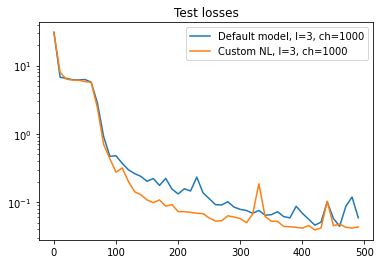

In [34]:
model5.plot_test_loss()
modelc2.plot_test_loss()